In [1]:
dvc = 'cpu'
from dolfinx import fem, mesh as msh
from dolfinx.io import XDMFFile
from mpi4py import MPI
from FEniCSx_solver import plot_fn
import torch
import ufl
import numpy as np
from FEniCSx_solver import interpolate_expr, SUPG_grad_adjoint_method_solver
from FEniCSx_PyTorch_interface import fem_solver


G = torch.load(f='data/revised_set/input_values/raw/G_0.pt', weights_only=False).to(device=dvc)

with XDMFFile(MPI.COMM_WORLD, f"data/revised_set/mesh_files/mesh_{0}.xdmf", "r") as xdmf:
    mesh = xdmf.read_mesh(name="mesh")
Wh = fem.functionspace(mesh=mesh, element=('CG', 1))
Whd = fem.functionspace(mesh=mesh, element=('DG', 0))
ufun = fem.Function(Wh)
ufun_d = fem.Function(Whd)
u = ufl.TrialFunction(Wh)
v = ufl.TestFunction(Wh)

mesh.topology.create_connectivity(1, 2)
boundary_facets = msh.exterior_facet_indices(mesh.topology)
boundary_dofs = fem.locate_dofs_topological(Wh, 1, boundary_facets)

x = ufl.SpatialCoordinate(mesh)
b = ufl.as_vector((fem.Constant(mesh, np.cos(-np.pi/3.0)), fem.Constant(mesh, np.sin(-np.pi/3.0))))
f = fem.Constant(mesh, 0.0)
eps = fem.Constant(mesh, 1e-8)

u = ufl.TrialFunction(Wh)
v = ufl.TestFunction(Wh)


expr = ufl.conditional(
    ufl.ge(x[1], 0.7 + ufl.sin(-ufl.pi/3)/ufl.cos(-ufl.pi/3)*x[0]),
    1,
    0
) * ufl.conditional(
    ufl.Or(ufl.eq(x[1], 0), ufl.eq(x[0],1)),
    0,
    1
)
uD = interpolate_expr(expr=expr, Wh=Wh)
bcs = [fem.dirichletbc(uD, boundary_dofs)]
pde_data = mesh,Wh,ufun,eps,b,None,f,None,bcs

u_target = fem.Function(Wh)
u_target.x.array[:] = torch.clone(G.u_bjk).cpu().detach().numpy()
loss_form = (ufun-u_target)**2 * ufl.dx
fs = fem_solver(SUPG_grad_adjoint_method_solver(pde_data=pde_data, loss_form=loss_form))




# Models and training

In [2]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from torch import nn
from IPython.display import clear_output
import numpy as np
import matplotlib.pyplot as plt
import torch_geometric as tg

dvc = 'cpu'
G = torch.load(f='data/revised_set/input_values/raw/G_0.pt', weights_only=False).to(device=dvc)
idofs = torch.clone(G.interior_dofs)


X = torch.clone(G.midpoints[:,0]).cpu().detach().numpy().flatten()
Y = torch.clone(G.midpoints[:,1]).cpu().detach().numpy().flatten()

Z0 = torch.clone(G.y_optimized_z).cpu().detach().numpy().flatten()
Z1 = torch.clone(G.y_optimized_z).cpu().detach().numpy().flatten()

z0 = torch.clone(G.y_optimized_z)
z1 = torch.clone(G.y_optimized_z)

curr_loss0 = 1e-2
curr_loss1 = 1e-2

target = torch.clone(G.y_optimized_z)[idofs]


class NN0(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.gat1 = tg.nn.models.GAT(
            in_channels=9,
            hidden_channels=256,
            num_layers=4,
            out_channels=256, 
            v2 = True,
            add_self_loops=False
        ).to(device=dvc)

        self.mlp_main = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        ).to(device=dvc)
        self.mlp_aux = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        ).to(device=dvc)

    def forward(self, data) -> torch.Tensor:
        x, edge_index  = data.x0, data.edge_index
        z = self.gat1(
            x=x,
            edge_index=edge_index
        )
        z_main = self.mlp_main(z)
        z_aux = self.mlp_aux(z)
        return z_main[idofs], z_aux[idofs]
    
class NN1(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.gat1 = tg.nn.models.GAT(
            in_channels=11,
            hidden_channels=256,
            num_layers=4,
            out_channels=256, 
            v2 = True,
            add_self_loops=False
        ).to(device=dvc)

        self.mlp_main = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        ).to(device=dvc)
        self.mlp_aux = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        ).to(device=dvc)

    def forward(self, data) -> torch.Tensor:
        x, edge_index  = data.x1, data.edge_index
        z = self.gat1(
            x=x,
            edge_index=edge_index
        )
        z_main = self.mlp_main(z)
        z_aux = self.mlp_aux(z)
        return z_main[idofs], z_aux[idofs]
    
model0 = NN0()
model1 = NN1()



huber = torch.nn.HuberLoss(reduction='sum')
l2 = torch.nn.MSELoss(reduction='sum')
def loss_fn(pred, target):
    return 0.7*huber(pred[0], target) + 0.3*l2(pred[1], target)



optimizer0 = torch.optim.Adam(model0.parameters(), lr=1e-3, weight_decay=1e-5)
optimizer1 = torch.optim.Adam(model1.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler0 = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer=optimizer0, T_0=50, T_mult=2)
scheduler1 = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer=optimizer1, T_0=50, T_mult=2)


losses0 = []
losses1 = []

losses_act0 = []
losses_act1 = []


In [3]:
checkpoint0 = torch.load("data/models/gat_revised0.pth", map_location=dvc)
model0.load_state_dict(checkpoint0["model_state"])
optimizer0.load_state_dict(checkpoint0["optimizer_state"])
curr_loss0 = checkpoint0.get("loss")

checkpoint1 = torch.load("data/models/gat_revised1.pth", map_location="cpu")
model1.load_state_dict(checkpoint1["model_state"])
optimizer1.load_state_dict(checkpoint1["optimizer_state"])
curr_loss1 = checkpoint1.get("loss")



lossarr0 = np.load('data/loss_arrays/gat_sup_loss_x0.npy')
lossarr1 = np.load('data/loss_arrays/gat_sup_loss_x1.npy')

act_lossarr0 = np.load('data/loss_arrays/gat_act_sup_loss_x0.npy')
act_lossarr1 = np.load('data/loss_arrays/gat_act_sup_loss_x1.npy')


losses0 = list(lossarr0)
losses1 = list(lossarr1)

losses_act0 = list(act_lossarr0)
losses_act1 = list(act_lossarr1)
z0[idofs] = model0(G)[0]
z1[idofs] = model1(G)[0]

curr_loss0 = fs(z0)
curr_loss1 = fs(z1)

print(curr_loss0, curr_loss1)

tensor(2.6600e-06, grad_fn=<FEniCSx_PyTorch_interfaceBackward>) tensor(4.5390e-05, grad_fn=<FEniCSx_PyTorch_interfaceBackward>)


In [6]:
from FEniCSx_solver import plot_fn
fs.fs.set_weights(torch.clone(z0).detach().cpu().detach().numpy().flatten())
plot_fn(fs.fs.uh)

Widget(value='<iframe src="http://localhost:63027/index.html?ui=P_0x3783dda90_2&reconnect=auto" class="pyvista…

epoch: 149000, supervised_loss: 4.918434e-02


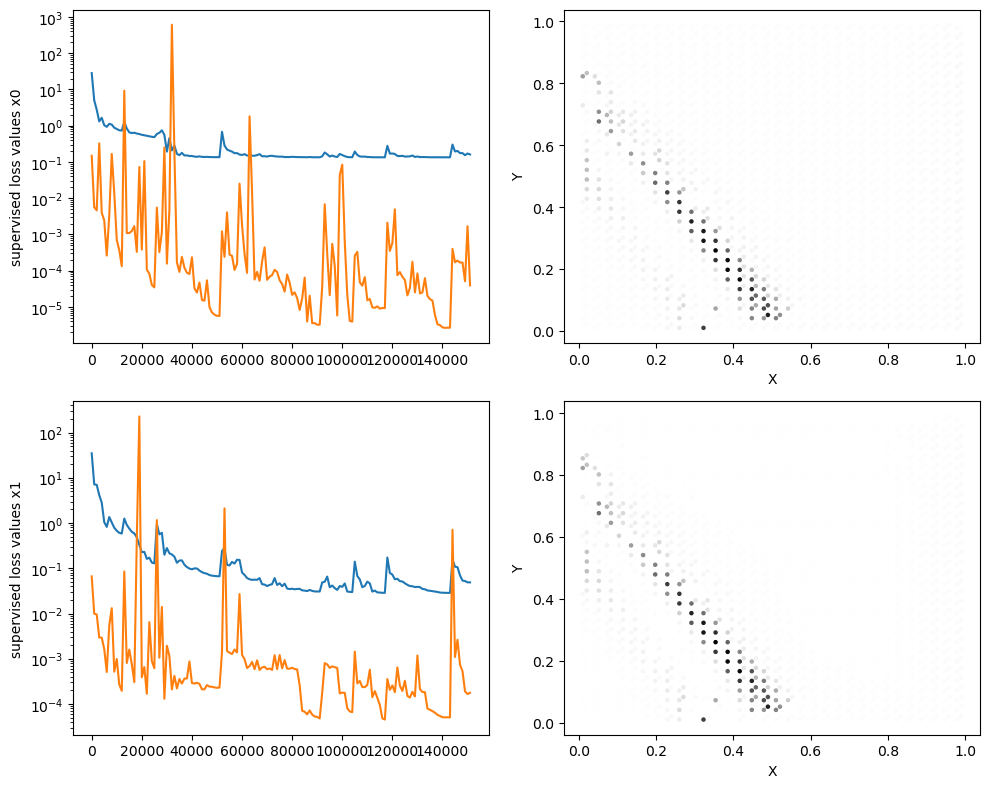

In [ ]:
'''
step = 1000
for i in range(90000, 150000):
    pred0 = model0(G)
    pred1 = model1(G)
    
    loss0 = loss_fn(pred0, target)
    loss1 = loss_fn(pred1, target)

    loss0.backward()
    loss1.backward()
    torch.nn.utils.clip_grad_norm_(
        model0.parameters(),
        max_norm=1.0
    )
    torch.nn.utils.clip_grad_norm_(
        model1.parameters(),
        max_norm=1.0
    )
    
    optimizer0.step()
    optimizer1.step()
    optimizer0.zero_grad()
    optimizer1.zero_grad()

    scheduler0.step()
    scheduler1.step()

    if i%step == 0:
        Z0[idofs] = torch.clone(model0(G)[0]).cpu().detach().numpy().flatten()
        z0[idofs] = model0(G)[0]
        Z1[idofs] = torch.clone(model1(G)[0]).cpu().detach().numpy().flatten()
        z1[idofs] = model1(G)[0]

        clear_output()
        losses0.append(loss_fn(model0(G), target).item())
        losses1.append(loss_fn(model1(G), target).item())

        act_loss0 = fs(z0)
        act_loss1 = fs(z1)

        losses_act0.append(act_loss0.item())
        losses_act1.append(act_loss1.item())

        if curr_loss0 > act_loss0:    
            print(f"iteration {i}: new loss0: {act_loss0}")
            curr_loss0 = act_loss0
            torch.save({'model_state': model0.state_dict(), 'optimizer_state': optimizer0.state_dict(), 'loss': act_loss0}, "data/models/gat_revised0.pth")
        if curr_loss1 > act_loss1:    
            print(f"iteration {i}: new loss1: {act_loss1}")
            curr_loss1 = act_loss1
            torch.save({'model_state': model1.state_dict(), 'optimizer_state': optimizer1.state_dict(), 'loss': act_loss1}, "data/models/gat_revised1.pth")

        print(f"epoch: {i}, supervised_loss: {loss1.item():3e}")
        lossarr0 = np.array(losses0)
        lossarr1 = np.array(losses1)

        act_lossarr0 = np.array(losses_act0)
        act_lossarr1 = np.array(losses_act1)
    
        fig, axes = plt.subplots(2, 2, figsize=(10, 8))

        ax11, ax12, ax21, ax22 = axes.flatten()

        x_vals = step*np.arange(len(lossarr1))
        ax11.plot(x_vals, lossarr0,  label='supervised_loss x0')
        ax11.plot(x_vals, act_lossarr0,  label='supervised_loss x0')
        ax11.set_ylabel('supervised loss values x0')

        ax11.set_yscale('log')
        ax11.tick_params(axis='y')

        ax21.plot(x_vals, lossarr1,  label='supervised_loss x1')
        ax21.plot(x_vals, act_lossarr1,  label='supervised_loss x1')
        ax21.set_ylabel('supervised loss values x1')

        ax21.set_yscale('log')
        ax21.tick_params(axis='y')

        
        ax12.scatter(X, Y, s=5, c=Z0, cmap='Greys')
        ax12.set_xlabel('X')
        ax12.set_ylabel('Y')

        ax22.scatter(X, Y, s=5, c=Z1, cmap='Greys')
        ax22.set_xlabel('X')
        ax22.set_ylabel('Y')

        np.save('data/loss_arrays/gat_sup_loss_x0.npy', lossarr0)
        np.save('data/loss_arrays/gat_sup_loss_x1.npy', lossarr1)


        np.save('data/loss_arrays/gat_act_sup_loss_x0.npy', act_lossarr0)
        np.save('data/loss_arrays/gat_act_sup_loss_x1.npy', act_lossarr1)


        plt.tight_layout()
        plt.show()
'''